# <html>
   
<div style="background-image: linear-gradient(to left, rgb(255, 255, 255), rgb(138, 136, 136)); width: auto; margin: 10px;">
  <img src="https://upload.wikimedia.org/wikipedia/en/thumb/f/fd/University_of_Tehran_logo.svg/225px-University_of_Tehran_logo.svg.png" width=100px width=auto style="padding:10px; vertical-align: center;">

</div>
   
<div   style:"text-align: center; background-image: linear-gradient(to left, rgb(255, 255, 255), rgb( 219, 204, 245  ));width: 400px; height: 30px; ">
<h1 style="font-family: Georgia; color: black; text-align: center; ">Course: Computer Vision </h1>

</div>
    <div   style:"border: 3px solid green;text-align: center; ">
<h1 style="font-family: Georgia; color: black; text-align: center; ">Project4 - Scikit Image </h1>

</div>

   <div>    
<h1 style="font-family: Georgia; color: black; text-align: center; font-size:15px;">Mohammad Amanlou- sid:810100084 </h1>
<h1 style="font-family: Georgia; color: black; text-align: center; font-size:15px;">Mobina Mehrazar- sid:810100236 </h1>
<h1 style="font-family: Georgia; color: black; text-align: center; font-size:15px;">Mohammad Amin Yousefi- sid:810100216 </h1>

</div>
   

</html>

# Comprehensive Guide to scikit-image
This Jupyter Notebook provides a complete, step-by-step guide to scikit-image for image processing.
Execute each cell to learn how to use different features of the library.

## Scikit Image Video Link: 
https://drive.google.com/file/d/1t-2u3VabO9CI2Ro37vhFQUa7xeP6QY1C/view?usp=sharing

## Installation & Setup

In [1]:
!pip install scikit-image matplotlib numpy scipy


# Comprehensive Guide to scikit-image

## Table of Contents
1. [Introduction](#introduction)
2. [Installation & Setup](#installation--setup)
3. [Basic Image I/O](#basic-image-io)
4. [Color Space Conversions](#color-space-conversions)
5. [Image Enhancement & Denoising](#image-enhancement--denoising)
6. [Thresholding & Binarization](#thresholding--binarization)
7. [Edge Detection & Contours](#edge-detection--contours)
8. [Morphological Operations](#morphological-operations)
9. [Geometric Transformations](#geometric-transformations)
10. [Segmentation Techniques](#segmentation-techniques)
11. [Feature Extraction & Object Measurement](#feature-extraction--object-measurement)
12. [Restoration & Deconvolution](#restoration--deconvolution)
13. [Practical Tips & Resources](#practical-tips--resources)

---

## Introduction
scikit-image is a powerful Python library for image processing, built on NumPy, SciPy, and matplotlib.
It provides ready-to-use implementations of many classic and modern algorithms, including:
- Filtering & Enhancement (Gaussian, median, etc.)
- Edge detection (Canny, Sobel, etc.)
- Thresholding & segmentation (Otsu, Watershed, SLIC, etc.)
- Morphological operations (dilation, erosion, opening, closing)
- Feature extraction (region properties, corners, blobs)

---


## Basic Image I/O

### ✅ **Scientific Explanation**

This code **loads an image** (`MMD.jpg`) into a NumPy array using `scikit-image` and **displays it** with `matplotlib`.

* **`io.imread()`** reads the image and converts it to numerical pixel data.
* **`plt.imshow()`** visualizes the image.
* **`plt.title()`** and **`plt.axis('off')`** make the display clean and labeled.
* **`plt.show()`** renders the output window.

This step is the **first stage of any computer vision pipeline**: acquiring and verifying image data.



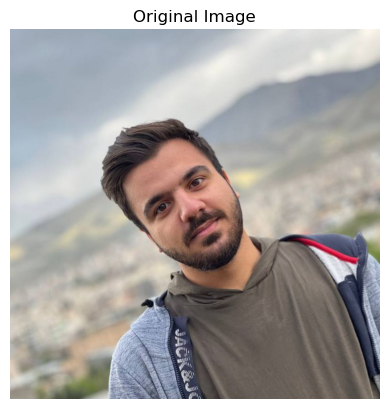

In [1]:
from skimage import io  # Import scikit-image I/O module for reading images
import matplotlib.pyplot as plt  # Import matplotlib for displaying the image

image = io.imread('MMD.jpg')  # Read the image; result is a NumPy array (H x W x Channels)

plt.imshow(image)  # Display the image as it is (RGB or grayscale)
plt.title("Original Image")  # Add a title to the image window
plt.axis('off')  # Hide axis ticks and labels for a cleaner view
plt.show()  # Render and show the image on the screen


In [3]:
io.imsave('output_image.jpg', image)

## Color Space Conversions

### ✅ **Scientific Explanation **

This code converts a loaded RGB image into **two different color spaces**:

1. **Grayscale (`rgb2gray`)**

   * Reduces the 3-channel RGB image to a single-channel intensity image.
   * Uses a weighted sum of R, G, and B channels, reflecting human visual perception (Green has the highest weight).
   * Useful for tasks like edge detection, thresholding, or segmentation where color is not essential.

2. **HSV (`rgb2hsv`)**

   * Converts RGB to **Hue, Saturation, and Value** color space.
   * **Hue** = color type, **Saturation** = color intensity, **Value** = brightness.
   * Useful for color-based segmentation and object detection because color (Hue) is separated from brightness.



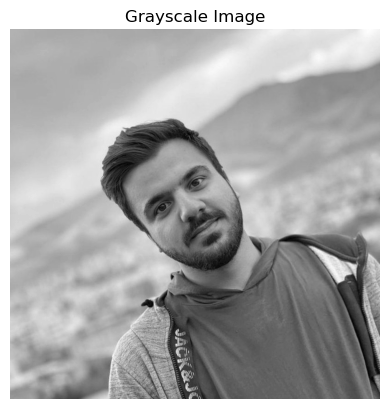

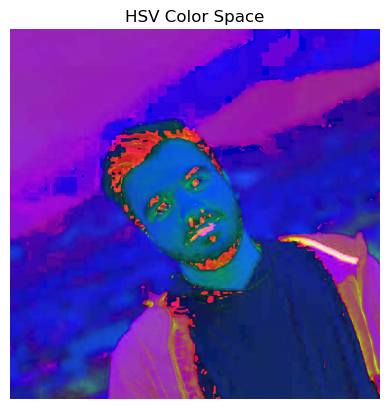

In [2]:
from skimage.color import rgb2gray, rgb2hsv  # Import color conversion functions

# ---- Grayscale Conversion ----
gray = rgb2gray(image)          # Convert RGB to grayscale (single channel, values 0.0 to 1.0)
plt.imshow(gray, cmap='gray')   # Display in grayscale colormap
plt.title("Grayscale Image")    # Title for visualization
plt.axis('off')                 # Hide axes for a clean display
plt.show()                      # Render and show the grayscale image

# ---- HSV Conversion ----
hsv = rgb2hsv(image)            # Convert RGB to HSV color space (3 channels: H, S, V)
plt.imshow(hsv)                 # Display HSV image (matplotlib interprets automatically)
plt.title("HSV Color Space")    # Title for visualization
plt.axis('off')                 # Hide axes
plt.show()                      # Render and show the HSV image


## Image Enhancement & Denoising

## **1. Gaussian Smoothing**

✅ **Gaussian filter** is used to **reduce noise** and **preserve edges better than simple averaging**.


### **Gaussian Smoothing (Blurring) – Scientific Explanation**

### **What is Gaussian Smoothing?**

* Gaussian smoothing is a **low-pass filter** that reduces image noise and detail by averaging neighboring pixels with **Gaussian weights**.
* The filter is based on the **Gaussian distribution** (bell curve), giving higher weight to pixels near the center and lower weight to farther pixels.
* It preserves edges better than a simple average filter because the weighting decreases smoothly with distance.

### **Mathematical Formula**

The Gaussian function in 2D is:

$$
G(x, y) = \frac{1}{2 \pi \sigma^2} e^{-\frac{x^2 + y^2}{2 \sigma^2}}
$$

* **σ (sigma):** Standard deviation controlling the amount of blur. Larger σ = stronger blur.
* Each pixel’s new value is the **weighted sum** of its neighbors according to G(x, y).

### **Why Use It?**

* **Noise Reduction:** Smooths random variations (e.g., salt-and-pepper or Gaussian noise).
* **Preprocessing Step:** Often applied before **edge detection** to reduce false edges.
* **Image Enhancement:** Can create a "soft" look in images.


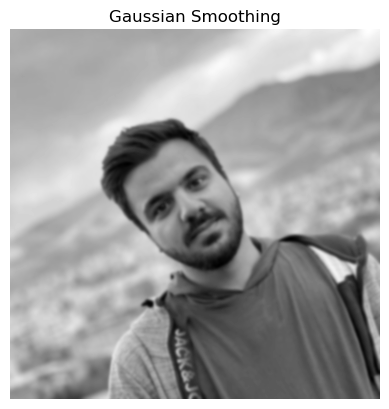

In [3]:
from skimage.filters import gaussian  # Import Gaussian filter function

blurred = gaussian(gray, sigma=2)     # Apply Gaussian smoothing; sigma=2 controls blur strength

plt.imshow(blurred, cmap='gray')      # Display the blurred (smoothed) grayscale image
plt.title("Gaussian Smoothing")       # Add a descriptive title
plt.axis('off')                       # Hide axes for a clean view
plt.show()                            # Render and display the result


### **2. Median Filtering (Salt-and-Pepper Noise Removal)**


### **What is the Median Filter?**

* The **median filter** is a **non-linear filtering technique** that replaces each pixel’s value with the **median** of the pixel intensities in its local neighborhood.
* Unlike Gaussian or mean filters, which compute an **average**, the median filter is excellent at **preserving edges** while removing noise.

---

### **Why Median Instead of Mean?**

* **Noise Removal (Especially Salt-and-Pepper Noise):**
  Median filtering is particularly effective against **impulse noise**, where some pixels are abnormally bright or dark.
* **Edge Preservation:**
  Since the median is a robust statistic, sharp edges are less blurred compared to mean or Gaussian filters.

---

### **How It Works?**

1. For each pixel, consider a neighborhood (a window, e.g., circular or square).
2. Sort the intensity values in that window.
3. Replace the pixel with the median value.

In this code, we use a **disk-shaped neighborhood** with radius `3`, which approximates a circular window

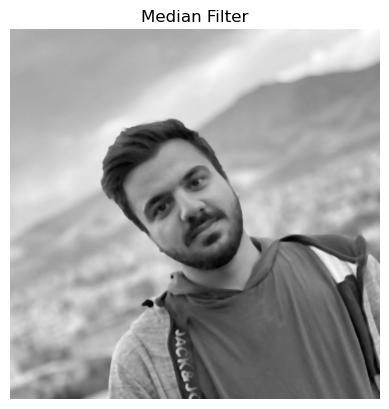

In [ ]:
from skimage.filters import median        # Import median filter function
from skimage.morphology import disk       # Import disk-shaped structuring element

median_filtered = median(gray, disk(3))   # Apply median filter with a disk-shaped neighborhood of radius 3

plt.imshow(median_filtered, cmap='gray')  # Display the median-filtered image in grayscale
plt.title("Median Filter")                # Add title to describe the output
plt.axis('off')                           # Hide axes for cleaner view
plt.show()                                # Render and show the filtered image


### **3. Histogram Equalization (Contrast Enhancement)**



### **What is Histogram Equalization?**

* Histogram equalization is a **contrast enhancement technique** that redistributes the intensity values of an image so that they cover the full range (0 to 1 or 0 to 255).
* It works by **spreading out the most frequent intensity values**, making dark regions brighter and bright regions darker if necessary.

---

### **Why Use It?**

* **Improves Visibility:** Enhances details in images with **low contrast** (e.g., underexposed or overexposed images).
* **Preprocessing for Computer Vision:** Better contrast helps algorithms like **edge detection** and **segmentation** perform more accurately.

---

### **How It Works?**

1. Compute the **histogram** (frequency distribution of pixel intensities).
2. Calculate the **cumulative distribution function (CDF)**.
3. Map original intensity values to new values based on the CDF so that the output histogram is approximately uniform.

Mathematically:

$$
I_{new} = (CDF(I_{old}) - CDF_{min}) \times \frac{L-1}{1 - CDF_{min}}
$$

Where **L** is the maximum intensity level.



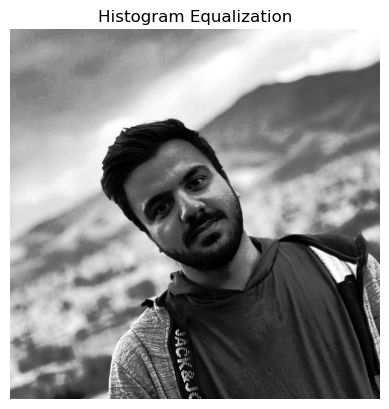

In [ ]:
from skimage import exposure                     # Import exposure module for contrast enhancement

equalized = exposure.equalize_hist(gray)         # Apply histogram equalization on grayscale image

plt.imshow(equalized, cmap='gray')               # Display the contrast-enhanced image
plt.title("Histogram Equalization")              # Title indicating the operation performed
plt.axis('off')                                  # Hide axes for clean visualization
plt.show()                                       # Render and show the result


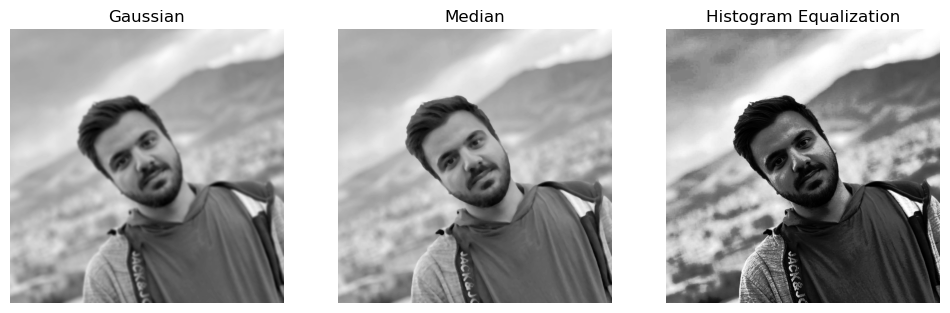

In [8]:

from skimage.filters import gaussian, median
from skimage.morphology import disk
from skimage import exposure

blurred = gaussian(gray, sigma=2)
median_filtered = median(gray, disk(3))
equalized = exposure.equalize_hist(gray)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(blurred, cmap='gray'); axes[0].set_title("Gaussian")
axes[1].imshow(median_filtered, cmap='gray'); axes[1].set_title("Median")
axes[2].imshow(equalized, cmap='gray'); axes[2].set_title("Histogram Equalization")
for ax in axes: ax.axis('off')
plt.show()


## Thresholding & Binarization

### **What is Thresholding?**

* Thresholding converts a grayscale image into a **binary (black & white)** image based on intensity values.
* Pixels **above the threshold** are considered **foreground (True/White)**, and pixels **below it** are **background (False/Black)**.

---

### **Otsu Thresholding**

* **Global method**: Finds a single optimal threshold that separates the foreground and background by maximizing the variance between the two classes.
* Works well when there’s a clear **bimodal histogram** (two distinct peaks).

### **Adaptive (Local) Thresholding**

* Calculates a **different threshold for each local region** (block).
* Useful for images with **uneven illumination**.

---

### **Why Use It?**

* **Preprocessing Step:** Essential for segmentation and object detection.
* **Noise Reduction:** Helps to isolate objects from the background.

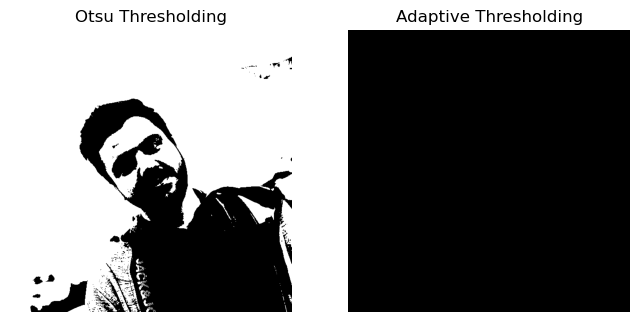

In [ ]:
from skimage.filters import threshold_otsu, threshold_local  # Import global and local thresholding methods

thresh = threshold_otsu(gray)               # Compute global Otsu threshold value
binary = gray > thresh                      # Create binary mask: True if pixel > thresh

local_thresh = threshold_local(gray,        # Compute local adaptive threshold
                               block_size=35,  # Size of local region for threshold calculation
                               offset=10)      # Adjusts sensitivity (positive = stricter threshold)
binary_local = gray > local_thresh          # Binary mask using local thresholds

fig, axes = plt.subplots(1, 2, figsize=(8, 4))  # Prepare a side-by-side display
axes[0].imshow(binary, cmap='gray'); axes[0].set_title("Otsu Thresholding")  # Show global result
axes[1].imshow(binary_local, cmap='gray'); axes[1].set_title("Adaptive Thresholding")  # Show local result
for ax in axes: ax.axis('off')              # Hide axes for clarity
plt.show()                                  # Render and show both results

## Edge Detection & Contours

### **What is Edge Detection?**

* Edge detection highlights regions in an image where there is a **rapid change in intensity** (high gradient).
* Edges usually correspond to **object boundaries**, making this step crucial for segmentation and object recognition.

---

### **Canny Edge Detector**

* A **multi-stage algorithm**:

  1. **Gaussian smoothing** to reduce noise.
  2. **Gradient calculation** to find edge strength and direction.
  3. **Non-maximum suppression** to thin edges.
  4. **Hysteresis thresholding** to keep only significant edges.
* Produces **thin and continuous edges**, robust to noise.

### **Sobel Operator**

* A simple **gradient-based filter** using convolution with Sobel kernels.
* Highlights edges by approximating intensity derivatives in both X and Y directions.
* Easier and faster than Canny but less precise (edges appear thicker).

---

### **Why Use Them?**

* **Preprocessing:** Essential for contour detection, segmentation, and shape analysis.
* **Canny:** Better for precise edge maps.
* **Sobel:** Quick and good for gradient visualization.

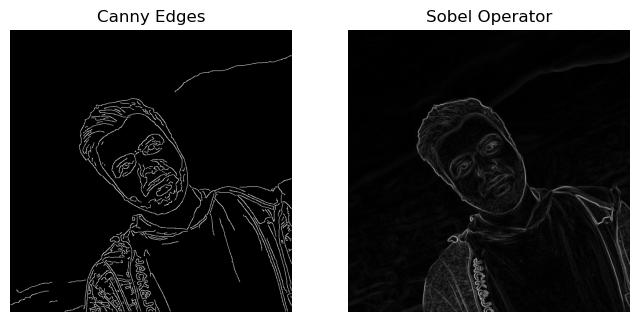

In [ ]:

from skimage.feature import canny           # Import Canny edge detector
from skimage.filters import sobel           # Import Sobel operator

edges = canny(gray, sigma=1.5)              # Apply Canny; sigma=1.5 for Gaussian smoothing before edge detection
edges_sobel = sobel(gray)                   # Apply Sobel operator for gradient-based edge detection

fig, axes = plt.subplots(1, 2, figsize=(8, 4))   # Display both results side by side
axes[0].imshow(edges, cmap='gray'); axes[0].set_title("Canny Edges")        # Show Canny result
axes[1].imshow(edges_sobel, cmap='gray'); axes[1].set_title("Sobel Operator") # Show Sobel result
for ax in axes: ax.axis('off')              # Hide axes for cleaner visualization
plt.show()                                  # Render and display both edge maps


## Morphological Operations


### **What are Morphological Operations?**

* Morphology in image processing refers to techniques that **analyze and modify the structure (shape) of objects** in binary or grayscale images.
* These operations are based on **set theory** and use a **structuring element** (like a disk or square) to probe the image.

---

### **Key Operations:**

#### **1. Dilation**

* **Adds pixels to object boundaries**.
* Useful for **filling small holes**, connecting broken parts of objects.

#### **2. Erosion**

* **Removes pixels from object boundaries**.
* Useful for **removing noise** and separating close objects.

#### **3. Opening (Erosion → Dilation)**

* **Removes small objects/noise** while preserving the shape of larger objects.

#### **4. Closing (Dilation → Erosion)**

* **Fills small holes or gaps** inside objects while keeping their outline.

---

### **Why Use Them?**

* Essential for **post-processing segmentation results**.
* Helps in **object cleaning, boundary refinement, and noise removal**.



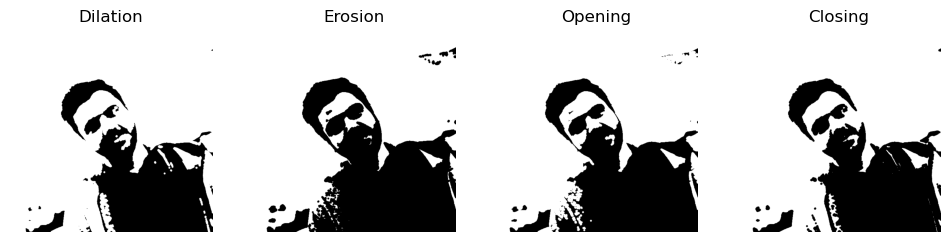

In [ ]:
from skimage.morphology import dilation, erosion, opening, closing  # Import basic morphological operations

# Apply operations with a disk-shaped structuring element of radius 3
dilated = dilation(binary, disk(3))   # Expand white regions, fill small gaps
eroded = erosion(binary, disk(3))     # Shrink white regions, remove thin noise
opened = opening(binary, disk(3))     # Remove small noise (erosion then dilation)
closed = closing(binary, disk(3))     # Fill small holes (dilation then erosion)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))  # Display results side by side
axes[0].imshow(dilated, cmap='gray'); axes[0].set_title("Dilation")
axes[1].imshow(eroded, cmap='gray'); axes[1].set_title("Erosion")
axes[2].imshow(opened, cmap='gray'); axes[2].set_title("Opening")
axes[3].imshow(closed, cmap='gray'); axes[3].set_title("Closing")
for ax in axes: ax.axis('off')                   # Hide axes for clean visualization
plt.show()                                       # Render and display all results

## Segmentation Techniques

### **What is Segmentation?**

* Segmentation divides an image into **meaningful regions** (e.g., objects vs. background).
* Crucial for **object detection, counting, and analysis**.

---

### **1. Watershed Segmentation**

* Based on **topographic interpretation**: the grayscale image is treated as a surface, where bright areas are peaks and dark areas are valleys.
* **Markers** define where “flooding” begins.
* The algorithm fills “basins” until boundaries meet, forming segment borders.
* Works best with a **distance transform** on binary masks for separating connected objects.

### **2. SLIC Superpixels (Simple Linear Iterative Clustering)**

* Groups pixels into visually coherent **superpixels** using **k-means-like clustering** in color and space.
* Useful for reducing computational complexity by working on superpixels instead of raw pixels.

---

### **Why Use Them?**

* **Watershed:** Separates touching objects (e.g., cells, coins).
* **SLIC:** Simplifies image for higher-level processing (object detection, segmentation).


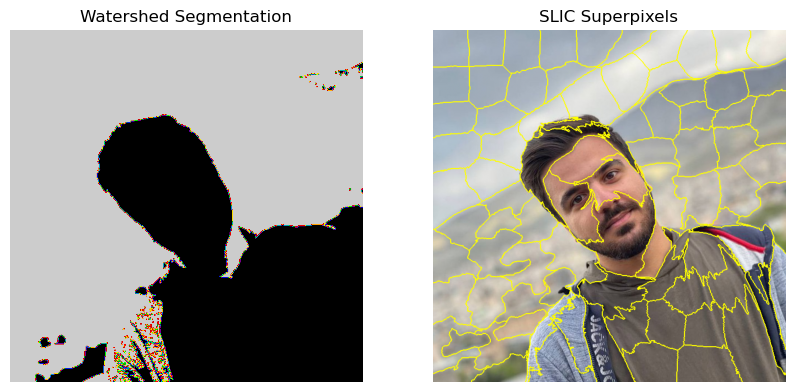

In [ ]:

from skimage.segmentation import watershed, slic, mark_boundaries  # Import segmentation tools
from scipy import ndimage as ndi                                   # For distance transform and labeling
import numpy as np

# ---- Watershed Segmentation ----
distance = ndi.distance_transform_edt(binary)        # Compute Euclidean distance from background
markers = ndi.label(distance > 0.4 * distance.max())[0]  # Create markers for watershed (foreground regions)
labels = watershed(-distance, markers, mask=binary)  # Apply watershed using negative distance (basins)

# ---- SLIC Superpixels ----
segments = slic(image, n_segments=100, compactness=10, start_label=1)  # Generate ~100 superpixels

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(labels, cmap='nipy_spectral'); axes[0].set_title("Watershed Segmentation")  # Color-coded segments
axes[1].imshow(mark_boundaries(image, segments)); axes[1].set_title("SLIC Superpixels")    # Boundaries drawn on original image
for ax in axes: ax.axis('off')  # Hide axes for clarity
plt.show()                      # Display both results


## Feature Extraction & Object Measurement

### **What is Feature Extraction & Object Measurement?**

* After segmentation, we often need to **analyze objects** by measuring their geometric and statistical properties.
* **Labeling** assigns a unique ID (label) to each connected component (object) in a binary image.
* **regionprops** calculates quantitative properties such as **area, perimeter, centroid, orientation, and bounding box**.

---

### **Why Use It?**

* Essential for **object counting**, **size measurement**, and **classification** in medical imaging, industrial inspection, etc.

---

### **Key Properties Available:**

* **Area:** Number of pixels in the object.
* **Perimeter:** Length of the object’s boundary.
* **Centroid:** Geometric center.
* **Bounding Box:** Rectangular region enclosing the object.


In [ ]:
from skimage.measure import label, regionprops  # Import labeling and region property functions

labeled = label(binary)                         # Label connected components in binary image
regions = regionprops(labeled)                  # Extract properties for each labeled region

# Print first 5 regions' properties
for r in regions[:5]:
    print(f"Label: {r.label}, Area: {r.area}, Perimeter: {r.perimeter}")
    # r.label     -> Unique ID of the object
    # r.area      -> Total pixels in the object
    # r.perimeter -> Boundary length of the object

Label: 1, Area: 263445.0, Perimeter: 7059.538777097872
Label: 2, Area: 1.0, Perimeter: 0.0
Label: 3, Area: 2.0, Perimeter: 0.0
Label: 4, Area: 1.0, Perimeter: 0.0
Label: 5, Area: 1.0, Perimeter: 0.0


## **Color Space Conversions**

`scikit-image` supports many color conversions: RGB, grayscale, HSV, LAB, etc.

### **1. Convert RGB → Grayscale**



### **What is Grayscale Conversion?**

* Converts a 3-channel RGB image into a **single-channel intensity image**.
* Uses a **weighted average** of R, G, and B channels, emphasizing the **green channel** (due to human eye sensitivity).
* Formula:

$$
Gray = 0.2125 \times R + 0.7154 \times G + 0.0721 \times B
$$

### **Why Use It?**

* **Simplifies processing**: Many algorithms (edge detection, thresholding) require a single intensity channel.
* **Reduces computation**: Less data to process compared to RGB.

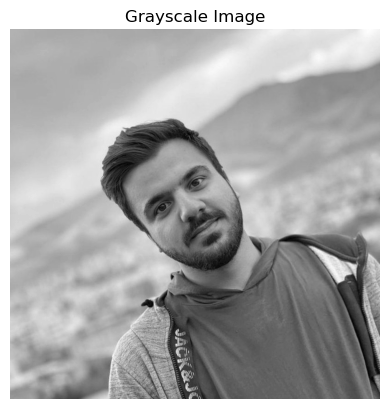

In [ ]:
from skimage.color import rgb2gray        # Import grayscale conversion function

gray = rgb2gray(image)                    # Convert RGB image to grayscale (values between 0 and 1)

plt.imshow(gray, cmap='gray')             # Display as grayscale image
plt.title("Grayscale Image")              # Add title to the plot
plt.axis('off')                           # Hide axes for cleaner visualization
plt.show()                                # Render and display the grayscale image

### **2. Convert RGB → HSV**

**Why HSV?**

* Useful for **color-based segmentation** (Hue separates color information from brightness).


### **What is HSV Color Space?**

* HSV stands for **Hue, Saturation, and Value**:

  * **Hue (H):** Represents the color type (angle on the color wheel).
  * **Saturation (S):** Intensity or purity of the color.
  * **Value (V):** Brightness of the color.
* Unlike RGB, HSV separates **color information (H)** from **brightness (V)**, making it more intuitive for human perception.

### **Why Use It?**

* **Color-based segmentation:** Easy to isolate objects by Hue regardless of brightness.
* **Object tracking & detection:** Robust against lighting changes since Hue is unaffected by illumination.

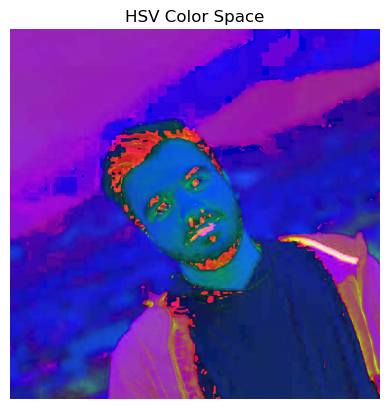

In [ ]:
from skimage.color import rgb2hsv        # Import function for RGB → HSV conversion

hsv = rgb2hsv(image)                     # Convert RGB image to HSV color space (3 channels: H, S, V)

plt.imshow(hsv)                          # Display HSV image (Matplotlib maps it automatically)
plt.title("HSV Color Space")              # Add title to indicate color space
plt.axis('off')                          # Hide axes for a cleaner display
plt.show()                               # Render and show the HSV image


## **Geometric Transformations**

### **Resizing & Rotation**



### **What are Geometric Transformations?**

* **Resize:** Changes the image dimensions (width & height) while interpolating pixel values.
* **Rotate:** Rotates the image by a specified angle around its center.

### **Why Use It?**

* **Preprocessing:** Standardizing input size for machine learning models.
* **Data Augmentation:** Rotating and resizing to artificially increase dataset diversity.
* **Alignment:** Rotating images for orientation correction.

### **Interpolation:**

* Resizing and rotating require estimating new pixel values using methods like **bilinear** or **bicubic interpolation** to avoid jagged edges.


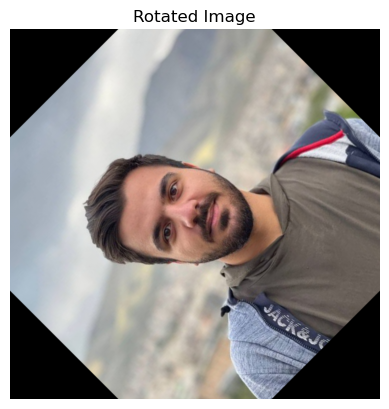

In [ ]:
from skimage.transform import resize, rotate   # Import functions for resizing and rotating

resized = resize(image, (128, 128))            # Resize the image to 128x128 pixels (returns float image 0-1)
rotated = rotate(image, 45)                    # Rotate image by 45 degrees (around center)

plt.imshow(rotated)                            # Display the rotated image
plt.title("Rotated Image")                      # Add title indicating rotation
plt.axis('off')                                # Hide axes for cleaner display
plt.show()                                     # Render and show the rotated image


## **Feature Extraction & Object Measurement**

### **1. Labeling & Region Properties**


### **What is Feature Extraction & Object Measurement?**

* After segmentation, we need to **analyze labeled objects** by measuring their geometric and statistical properties.
* **Labeling:** Assigns a unique ID to each connected component in a binary image.
* **regionprops:** Calculates quantitative properties such as **area, perimeter, centroid, bounding box**, etc.

### **Why Use It?**

* **Object Counting:** Count number of segmented objects.
* **Size & Shape Analysis:** Measure area, perimeter, orientation.
* **Classification:** Useful in medical imaging, industrial inspection, etc.

---

### **Key Properties Measured:**

* **Label:** Unique identifier for each object.
* **Area:** Number of pixels belonging to the object.
* **Perimeter:** Length of the object boundary.

In [ ]:
from skimage.measure import label, regionprops  # Import labeling and region property functions

labeled = label(binary)                         # Label connected components (assign unique ID to each object)
regions = regionprops(labeled)                  # Extract properties for each labeled region

# Print properties for all labeled regions
for r in regions:
    print(f"Label: {r.label}, Area: {r.area}, Perimeter: {r.perimeter}")
    # r.label     -> Unique ID for the object
    # r.area      -> Total pixels inside the object
    # r.perimeter -> Boundary length of the object

Label: 1, Area: 263445.0, Perimeter: 7059.538777097872
Label: 2, Area: 1.0, Perimeter: 0.0
Label: 3, Area: 2.0, Perimeter: 0.0
Label: 4, Area: 1.0, Perimeter: 0.0
Label: 5, Area: 1.0, Perimeter: 0.0
Label: 6, Area: 13794.0, Perimeter: 1317.76973209045
Label: 7, Area: 4.0, Perimeter: 4.0
Label: 8, Area: 6.0, Perimeter: 6.414213562373095
Label: 9, Area: 3.0, Perimeter: 1.2071067811865475
Label: 10, Area: 4.0, Perimeter: 2.0
Label: 11, Area: 1.0, Perimeter: 0.0
Label: 12, Area: 23.0, Perimeter: 18.27817459305202
Label: 13, Area: 32.0, Perimeter: 22.727922061357855
Label: 14, Area: 1435.0, Perimeter: 177.43250352560273
Label: 15, Area: 567.0, Perimeter: 191.40916292848976
Label: 16, Area: 3.0, Perimeter: 3.414213562373095
Label: 17, Area: 26.0, Perimeter: 18.863961030678926
Label: 18, Area: 2.0, Perimeter: 0.0
Label: 19, Area: 26.0, Perimeter: 18.899494936611667
Label: 20, Area: 1.0, Perimeter: 0.0
Label: 21, Area: 1.0, Perimeter: 0.0
Label: 22, Area: 30.0, Perimeter: 20.863961030678926
La

### **2. Corner Detection (Harris)**


### **What is Corner Detection?**

* Corners are points where **two edges meet**; they have high variation in intensity in **both x and y directions**.
* The **Harris corner detector** identifies such points by analyzing the **autocorrelation matrix** of gradients in a local window.

### **Why Use It?**

* **Feature Matching:** Key points for tracking or stitching images.
* **Object Recognition:** Corners are stable and distinctive features.

### **How Harris Works?**

* Computes gradient changes within a small window.
* Uses the **Harris response function** to score each pixel; higher scores indicate stronger corners.

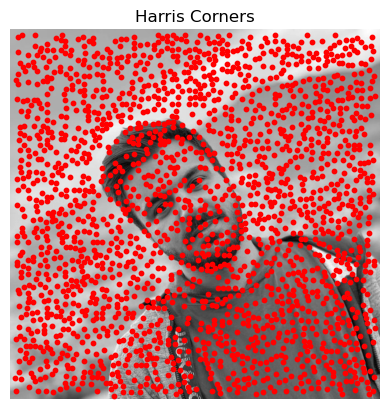

In [ ]:
from skimage.feature import corner_harris, corner_peaks  # Import Harris detector and peak extractor

coords = corner_peaks(corner_harris(gray), min_distance=5)  # Detect corners, keeping peaks at least 5 pixels apart

plt.imshow(gray, cmap='gray')                               # Display grayscale image
plt.scatter(coords[:, 1], coords[:, 0], color='red', s=10)   # Plot red points at detected corner coordinates
plt.title("Harris Corners")                                 # Add title to indicate corner detection
plt.axis('off')                                              # Hide axes for a cleaner view
plt.show()                                                   # Render and display the result

## **Restoration & Deconvolution**

### **1. Denoising (Non-Local Means)**

### **What is Non-Local Means (NLM) Denoising?**

* NLM is an advanced denoising algorithm that **removes noise** while preserving image details and textures.
* Unlike simple filters (mean, Gaussian), NLM compares **patches** of pixels across the entire image, not just local neighborhoods.
* Similar patches are averaged, reducing random noise while keeping structural details.

### **Why Use It?**

* **High-Quality Denoising:** Suitable for medical and scientific images where detail preservation is critical.
* **Better than Local Filters:** Maintains edges and fine textures.

### **Key Parameter:**

* **h (Filtering Strength):** Larger `h` results in stronger denoising but may blur details.
* **sigma\_est:** Estimated standard deviation of noise; used to adaptively set `h`.

In [ ]:
from skimage.restoration import denoise_nl_means, estimate_sigma  # Import NLM denoising and noise estimation

sigma_est = np.mean(estimate_sigma(image, channel_axis=-1))        # Estimate noise level across color channels
denoised = denoise_nl_means(image,                                 # Apply Non-Local Means denoising
                            h=1.15 * sigma_est,                    # Filtering strength proportional to noise
                            fast_mode=True)                        # Fast approximation mode for speed

plt.imshow(denoised)                                               # Display the denoised image
plt.title("Non-Local Means Denoising")                              # Add title describing the operation
plt.axis('off')                                                     # Hide axes for cleaner view
plt.show()                                                          # Render and show the denoised image

## **Practical Tips & Resources**

### **Official Documentation**

* [scikit-image Docs](https://scikit-image.org/docs/stable/)
* [Gallery of Examples](https://scikit-image.org/docs/stable/auto_examples/)

### **Books & References**

* **Digital Image Processing – Gonzalez & Woods**
* **Python Image Processing Cookbook – Sandipan Dey**

---

## Scikit Image Video Link: 
https://drive.google.com/file/d/1t-2u3VabO9CI2Ro37vhFQUa7xeP6QY1C/view?usp=sharing